In [1]:
# ==========
# Unzip file
# ==========
!unzip ratings.csv.zip

Archive:  ratings.csv.zip
  inflating: ratings.csv             


In [2]:
# =========
# Load file
# =========
import pandas as pd
ratings=pd.read_csv('ratings.csv')

In [3]:
# =========
# Data info
# =========
print(ratings.shape)
print(ratings.head())
print(ratings.info())

print("Unique users:", ratings['userId'].nunique())
print("Unique movies:", ratings['movieId'].nunique())

ratings['rating'].value_counts().sort_index()

user_avg = ratings.groupby('userId')['rating'].mean()
movie_avg = ratings.groupby('movieId')['rating'].mean()

print("average rating per user",user_avg.mean())
print("average rating per movie",movie_avg.mean())

ratings_per_user = ratings.groupby('userId')['rating'].count()

avg_ratings_per_user = ratings_per_user.mean()
min_ratings_per_user = ratings_per_user.min()

print("Average number of ratings per user:", avg_ratings_per_user)
print("Minimum number of ratings per user:", min_ratings_per_user)

ratings_per_movie = ratings.groupby('movieId')['rating'].count()

avg_ratings_per_movie = ratings_per_movie.mean()
min_ratings_per_movie = ratings_per_movie.min()

print("Average number of ratings per movie:", avg_ratings_per_movie)
print("Minimum number of ratings per movie:", min_ratings_per_movie)

(100836, 4)
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
None
Unique users: 610
Unique movies: 9724
average rating per user 3.6572223377474
average rating per movie 3.262448274810963
Average number of ratings per user: 165.30491803278687
Minimum number of ratings per user: 20
Average number of ratings per movie: 10.369806663924312
Minimum number of ratings per movie: 1


In [4]:
# =============
# Preprocessing
# =============
import numpy as np
from sklearn.preprocessing import MinMaxScaler

ratings = ratings.drop(columns=['timestamp'])

min_movie_ratings = 5
movie_counts = ratings['movieId'].value_counts()
ratings = ratings[ratings['movieId'].isin(movie_counts[movie_counts >= min_movie_ratings].index)]

scaler = MinMaxScaler()
ratings['rating']=scaler.fit_transform(ratings[['rating']])

user_ids= ratings['userId'].unique().tolist()
user2user_encoded = {x: i for i, x in enumerate(user_ids)}
movie_ids = ratings['movieId'].unique().tolist()
movie2movie_encoded = {x: i for i, x in enumerate(movie_ids)}
ratings['user'] = ratings['userId'].map(user2user_encoded)
ratings['movie'] = ratings['movieId'].map(movie2movie_encoded)

movie_encoded2movie = {x: i for i, x in movie2movie_encoded.items()}

num_users = len(user2user_encoded)
num_movies = len(movie2movie_encoded)

print(ratings['rating'].dtype)
ratings['rating'] = ratings['rating'].values.astype(np.float32)

float64


In [5]:
# =============================
# User-wise Train-Test split
# =============================
train_rows=[]
test_rows=[]

count=0

for user_id, user_data in ratings.groupby('user'):
    n_items = len(user_data)
    user_data = user_data.sample(frac=1, random_state=42)

    if n_items<=1:
      count+=1

    train_size = max(1, int(0.8 * n_items))
    test_size = max(1, n_items - train_size)

    train_rows.append(user_data.iloc[:train_size])
    test_rows.append(user_data.iloc[train_size:train_size+test_size])

train_df = pd.concat(train_rows)
test_df = pd.concat(test_rows)
print(count)

0


In [6]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (71971, 5)
Test shape: (18303, 5)


In [7]:
# ============================
# Prepare Train/Test Arrays
# ============================
X_train=[train_df['user'].values, train_df['movie'].values]
X_test=[test_df['user'].values, test_df['movie'].values]

y_train=train_df['rating'].values
y_test=test_df['rating'].values

In [8]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Dense, Dropout, Multiply, Flatten, Concatenate, BatchNormalization
from tensorflow.keras.models import Model

# ===============
# Define Model
# ===============

embedding_size = 32

user_input = Input(shape=(1,), name="user_input")
movie_input = Input(shape=(1,), name="movie_input")

user_embedding = Embedding(num_users, embedding_size, embeddings_initializer="he_normal")(user_input)
movie_embedding = Embedding(num_movies, embedding_size, embeddings_initializer="he_normal")(movie_input)

user_vec = Flatten()(user_embedding)
movie_vec = Flatten()(movie_embedding)

concat = Concatenate()([user_vec, movie_vec])

dense = Dense(256, activation='relu')(concat)
dense = BatchNormalization()(dense)
dense = Dropout(0.5)(dense)

dense = Dense(128, activation='relu')(dense)
dense = BatchNormalization()(dense)
dense = Dropout(0.4)(dense)

dense = Dense(64, activation='relu')(dense)
dense = BatchNormalization()(dense)

output = Dense(1, activation='sigmoid')(dense)

model = Model(inputs=[user_input, movie_input], outputs=output)

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 32)     │     19,520 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 32)     │    116,800 │ movie_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 32)        │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 32)        │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64)        │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │     16,640 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         65 │ batch_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 195,969 (765.50 KB)

 Trainable params: 195,073 (762.00 KB)

 Non-trainable params: 896 (3.50 KB)

In [9]:
# ==============
# Train Model
# ==============

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("ncf_best_model.h5", save_best_only=True)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0805 - mae: 0.2260

282/282 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - loss: 0.0805 - mae: 0.2259 - val_loss: 0.0511 - val_mae: 0.1801
Epoch 2/20
278/282 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0470 - mae: 0.1699

282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0470 - mae: 0.1699 - val_loss: 0.0416 - val_mae: 0.1613
Epoch 3/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0387 - mae: 0.1522

282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0387 - mae: 0.1522 - val_loss: 0.0378 - val_mae: 0.1511
Epoch 4/20
281/282 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0361 - mae: 0.1466

282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0361 - mae: 0.1466 - val_loss: 0.0369 - val_mae: 0.1482
Epoch 5/20
281/282 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0344 - mae: 0.1429

282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.0344 - mae: 0.1429 - val_loss: 0.0363 - val_mae: 0.1470
Epoch 6/20
277/282 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0330 - mae: 0.1399

282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0330 - mae: 0.1399 - val_loss: 0.0362 - val_mae: 0.1459
Epoch 7/20
280/282 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0323 - mae: 0.1382

282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0323 - mae: 0.1382 - val_loss: 0.0358 - val_mae: 0.1455
Epoch 8/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0316 - mae: 0.1362 - val_loss: 0.0359 - val_mae: 0.1452
Epoch 9/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0304 - mae: 0.1338 - val_loss: 0.0365 - val_mae: 0.1459
Epoch 10/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0291 - mae: 0.1309 - val_loss: 0.0366 - val_mae: 0.1466


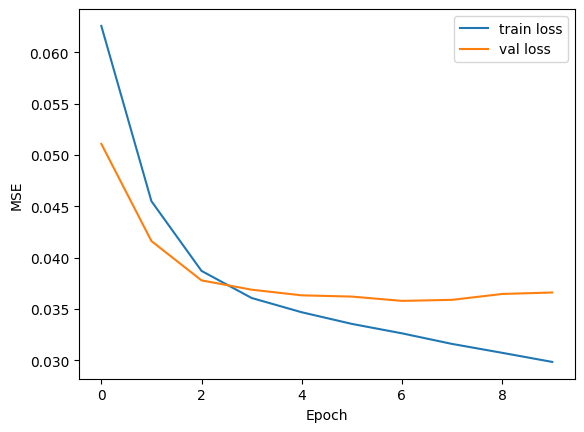

In [10]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()

In [12]:
# ===========================
# Evaluate on Test Data
# ===========================
from sklearn.metrics import mean_squared_error
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=1)

y_pred = model.predict(X_test, verbose=0).flatten()
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

metrics_text = (
    f"Test Loss (MSE): {test_loss:.4f}\n"
    f"Test MAE: {test_mae:.4f}\n"
    f"Test RMSE: {rmse:.4f}\n"
)

# Save metrics to file
with open("/content/metrics.txt", "w") as f:
    f.write(metrics_text)


572/572 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0371 - mae: 0.1482


In [13]:
# ===============
# Prediction
# ===============
user_id = 1
movie_id = 50

user_enc = user2user_encoded[user_id]
movie_enc = movie2movie_encoded[movie_id]

pred_scaled = model.predict([np.array([user_enc]), np.array([movie_enc])], verbose=0)[0][0]

pred_original = scaler.inverse_transform([[pred_scaled]])[0][0]

print(f"Predicted rating (scaled 0-1): {pred_scaled:.3f}")
print(f"Predicted rating (original scale): {pred_original:.2f}")

Predicted rating (scaled 0-1): 0.934
Predicted rating (original scale): 4.70


In [14]:
# ===================
# Original rating
# ===================
user_id = 1
movie_id = 50

rating_row = ratings[(ratings['userId'] == user_id) & (ratings['movieId'] == movie_id)]

if not rating_row.empty:
    original_rating = rating_row['rating'].values[0]*5
    print(f"User {user_id} rated movie {movie_id} as {original_rating}")
else:
    print(f"No rating found for user {user_id} and movie {movie_id}")


User 1 rated movie 50 as 5.0


In [15]:
# ===============
# Recommender
# ===============
def recommend_movies(user_id, model, user2user_encoded, movie2movie_encoded, movie_encoded2movie, train_df, num_movies, top_n=10):
    # Encode user
    user_enc = user2user_encoded[user_id]

    # All encoded movies
    all_movie_ids = np.arange(num_movies)

    # Movies the user has already rated in training
    movies_rated = train_df[train_df['user'] == user_enc]['movie'].values

    # Candidate movies (unseen by user)
    movies_to_predict = np.setdiff1d(all_movie_ids, movies_rated)

    # Prepare input arrays
    user_array = np.full(len(movies_to_predict), user_enc)

    # Predict scores
    preds = model.predict([user_array, movies_to_predict], verbose=0).flatten()

    # Sort by predicted score
    top_indices = movies_to_predict[np.argsort(preds)[::-1][:top_n]]

    # Map back to original movie IDs
    recommended_movie_ids = [movie_encoded2movie[i] for i in top_indices]

    return recommended_movie_ids

recommended_movies = recommend_movies(
    user_id=1,
    model=model,
    user2user_encoded=user2user_encoded,
    movie2movie_encoded=movie2movie_encoded,
    movie_encoded2movie=movie_encoded2movie,
    train_df=train_df,
    num_movies=num_movies,
    top_n=10
)

print("Top 10 recommended movies for user 1:", recommended_movies)

Top 10 recommended movies for user 1: [3266, 7008, 2360, 4021, 2732, 3201, 3200, 318, 6666, 3182]
